# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what? **What makes a model linear is that it is linear in its coefficients/parameters. This is necessarily independent of the input variables, so long as the coefficients are not passed through any nonlinear funcitons.**
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?) **The coefficient for a one-hot-encoded variable is interpreted as the difference in actual outcome/output relative to a baseline category. In evaluating this, you also hold all of the other variables constant.**
3. Can linear regression be used for classification? Explain why, or why not.**Technically yes, but in practice no. The thing about linear regression is that it outputs continuous values, so it's not nice for classification/probability where you need it to fall within \[0,1\]. Logisitic regression is definitely the better method for classification.**
4. What are signs that your linear model is over-fitting? **I would say the biggest sign is performance on new/unseen data. If your model is doing amazing on your training data, but then poorly on new data, it's a very likely sign that your model is over-fitting. On a similar regard, having low training error but high test error is a similar sign that your model is over-fitting.**
5. Clearly explain multi-colinearity using the two-stage least squares technique. **At a high level, mult-colinearity has very little unique variation once you take out the part explained by other predictors. It means that one variable doesn't add much new information beyond what other variables already explain, so when you isolate the "new" part, there's very little left to estimate its effect reliably. In terms of the the two-stage least squares technique, you first regress a predictor (x1) on the other predictors and get the residual, and then regress y on this residual. If x1 is highly correlated with other predictors, the residual will have very little variation, as we have mentioned above.**
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis? **The idea is to transform the inputs and not the actual model structure/feature space. You can do this by adding polynomial terms (x^2), interaction terms (x1 * x2), transformations of variables (sqrt(x)), and many other techniques that follow this same restriction.**
7. What is the interpretation of the slope coefficient in a linear regression? **It's the expected change in Y per unit increase in X, where Y is the dependent variable and X is the independent variable.**
8. Compare the train/test split and $k$-fold cross validation. **Train/test splits once, whereas k-fold splits data into k parts. Train/Test is fast and simple, but depending on the split it can cause high variance. k-fold trains on k-1, and then tests on remaining fold, and you'll repeat this k times. Evidently, k-fold is a lot more expensive but it is most definitely more reliable.**
9. How is the $k$ in $k$-fold cross validation typically selected? **It's selected by finding the balance between efficiency of compute vs. estimate stability. Smaller k gets you higher bias, but it is faster. Larger k is the opposite. Standard values of k are known to be either 5 or 10.**

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`. **We can see that Manhattan is the most expensive on average (code below).**


   price  review_score neighbourhood Property Type        Room Type  log_price
0    549          96.0     Manhattan     Apartment     Private room   6.308098
1    149         100.0      Brooklyn     Apartment  Entire home/apt   5.003946
2    250         100.0     Manhattan     Apartment  Entire home/apt   5.521461
3     90          94.0      Brooklyn     Apartment     Private room   4.499810
4    270          90.0     Manhattan     Apartment  Entire home/apt   5.598422
neighbourhood
Manhattan        11763
Brooklyn          8487
Queens            1590
Bronx              217
Staten Island       96
Name: count, dtype: int64

Group means by neighbourhood
                avg_price  avg_review_score      n
neighbourhood                                     
Manhattan      183.664286         91.801496  11763
Staten Island  146.166667         90.843750     96
Brooklyn       127.747378         92.363497   8487
Queens          96.857233         91.549057   1590
Bronx           75.276498         9

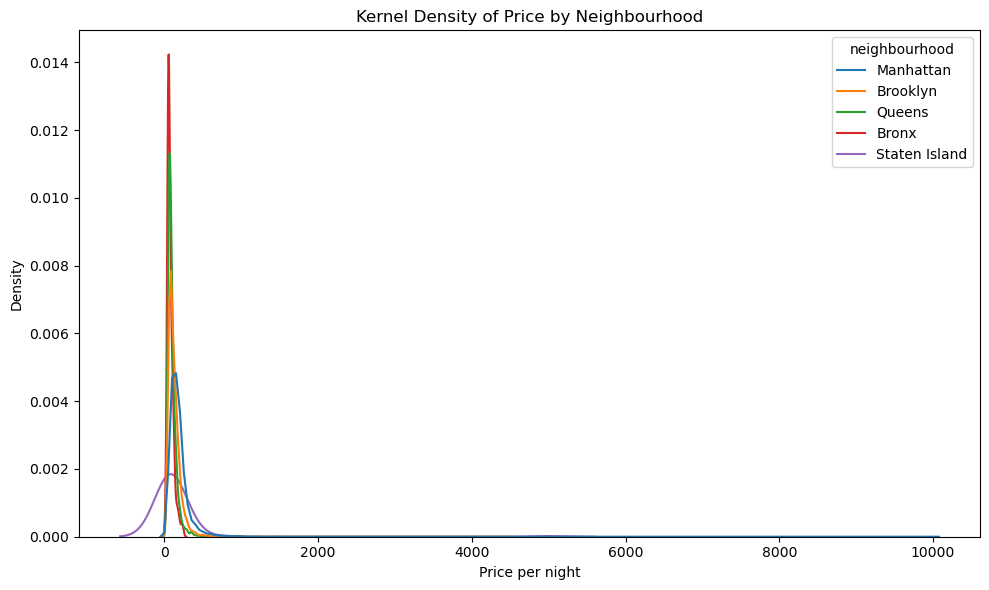

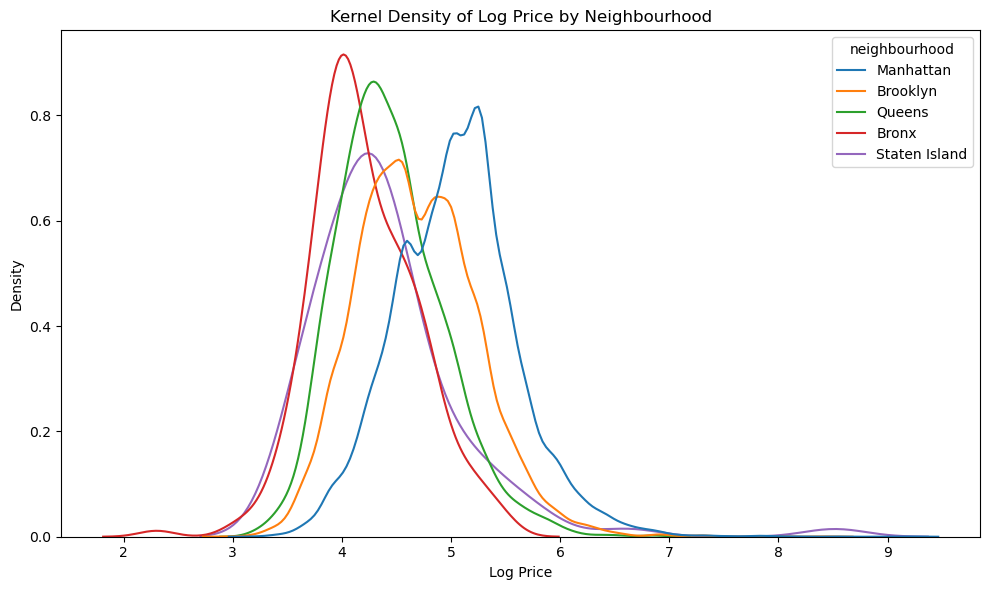

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.model_selection import KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, make_scorer

df = pd.read_csv("./data/Q1_clean.csv")
# renaming columns so easier to work with going forward
df = df.rename(columns={
    "Price": "price",
    "Review Scores Rating": "review_score",
    "Neighbourhood ": "neighbourhood"
})
df["log_price"] = np.log(df["price"])
print(df.head())
print(df["neighbourhood"].value_counts())
group_means = (
    df.groupby("neighbourhood")
      .agg(
          avg_price=("price", "mean"),
          avg_review_score=("review_score", "mean"),
          n=("price", "size")
      )
      .sort_values("avg_price", ascending=False)
)
print("\nGroup means by neighbourhood")
print(group_means)
most_expensive = group_means["avg_price"].idxmax()
print(f"\nMost expensive borough on average: {most_expensive}")

plt.figure(figsize=(10, 6)) #price
sns.kdeplot(data=df, x="price", hue="neighbourhood", fill=False, common_norm=False)
plt.title("Kernel Density of Price by Neighbourhood")
plt.xlabel("Price per night")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6)) #log price
sns.kdeplot(data=df, x="log_price", hue="neighbourhood", fill=False, common_norm=False)
plt.title("Kernel Density of Log Price by Neighbourhood")
plt.xlabel("Log Price")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related? **I am dropping the first category. The conditional group means and the estimated coefficients are related in the sense that the coefficients are a reparameterization of the conditional group means, where the intercept equals the mean of the baseline group, and each dummy coefficient measures the difference between the group's mean and the baseline mean.**


In [40]:

m1 = smf.ols("price ~ C(neighbourhood)", data=df).fit()
print(m1.summary())
print("\nCoefficients:")
print(m1.params)
print(group_means["avg_price"])

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Sun, 22 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        14:28:54   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words. **The slope coefficient is the expected change in price for a unit-point increase in review score (on average). Here, a 1-point increase in review score is associated with about 1.02 price, on average.**


In [41]:
m2 = smf.ols("price ~ review_score", data=df).fit()
print(m2.summary())
print("\nCoefficients:")
print(m2.params)

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        14:28:54   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       60.8784     10.423      5.841   

4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change? **The slope goes up very slightly after controlling neighborhood, suggesting that ratings have a small positive association with price, but neighborhood is doing much more on the explanatory side.**


In [42]:
m3 = smf.ols("price ~ C(neighbourhood) + review_score", data=df).fit()
print(m3.summary())
print("\nCoefficients:")
print(m3.params)
print("\nCompare review_score slopes:")
print(f"Part 3 slope: {m2.params['review_score']:.4f}")
print(f"Part 4 slope: {m3.params['review_score']:.4f}")

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Sun, 22 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        14:28:54   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not? **They are mostly similar across neighborhoods, but Staten Island is a bit of an outlier (maybe due to it having a lot less observations than the others).**


In [43]:
m4 = smf.ols("price ~ C(neighbourhood) * review_score", data=df).fit()
print(m4.summary())
print("\nCoefficients:")
print(m4.params)
baseline_slope = m4.params["review_score"]
print(f"\nBaseline slope (Bronx): {baseline_slope:.4f}")
neighbourhoods = sorted(df["neighbourhood"].unique())
slopes = {}
for nb in neighbourhoods:
    if nb == "Bronx":
        slopes[nb] = baseline_slope
    else:
        interaction_name = f"C(neighbourhood)[T.{nb}]:review_score"
        slopes[nb] = baseline_slope + m4.params[interaction_name]

print("\n Slope of review_score by neighbourhood")
for nb, slope in slopes.items():
    print(f"{nb}: {slope:.4f}")

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Sun, 22 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:28:55   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [44]:
def rmse_cv(model, X, y): #rmse helper for the models
    scores = cross_val_score(
        model, X, y,
        cv=10,
        scoring="neg_mean_squared_error"
    )
    return np.sqrt(-scores).mean()
# part 3
X1 = df[["review_score"]]
y = df["price"]
model1 = LinearRegression()
rmse1 = rmse_cv(model1, X1, y)

# part 4
X2 = df[["review_score", "neighbourhood"]]
preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first"), ["neighbourhood"]),
    ("num", "passthrough", ["review_score"])
])
model2 = Pipeline([
    ("preprocess", preprocess),
    ("model", LinearRegression())
])
rmse2 = rmse_cv(model2, X2, y)

#part 5
from patsy import dmatrices
y_mat, X_mat = dmatrices(
    "price ~ C(neighbourhood) * review_score",
    data=df,
    return_type="dataframe"
)
model3 = LinearRegression()
rmse3 = rmse_cv(model3, X_mat, y_mat.values.ravel())
print("RMSE (review_score only):", rmse1)
print("RMSE (neighbourhood + review_score):", rmse2)
print("RMSE (interaction model):", rmse3)

RMSE (review_score only): 144.39260955209576
RMSE (neighbourhood + review_score): 140.76197488120323
RMSE (interaction model): 141.54341201101826


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance? **SUV's are most expensive on averagge, and also happen to have the most variance (highest std. dev).**


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


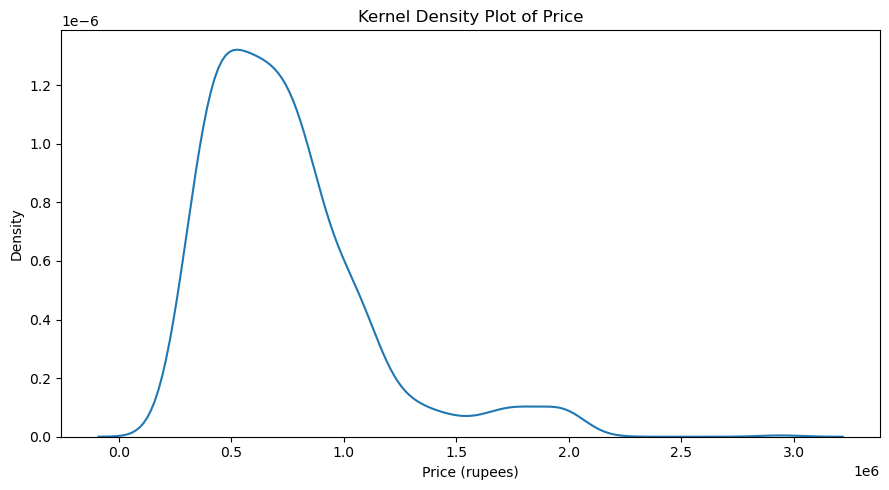


price summary by Body_Type
           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


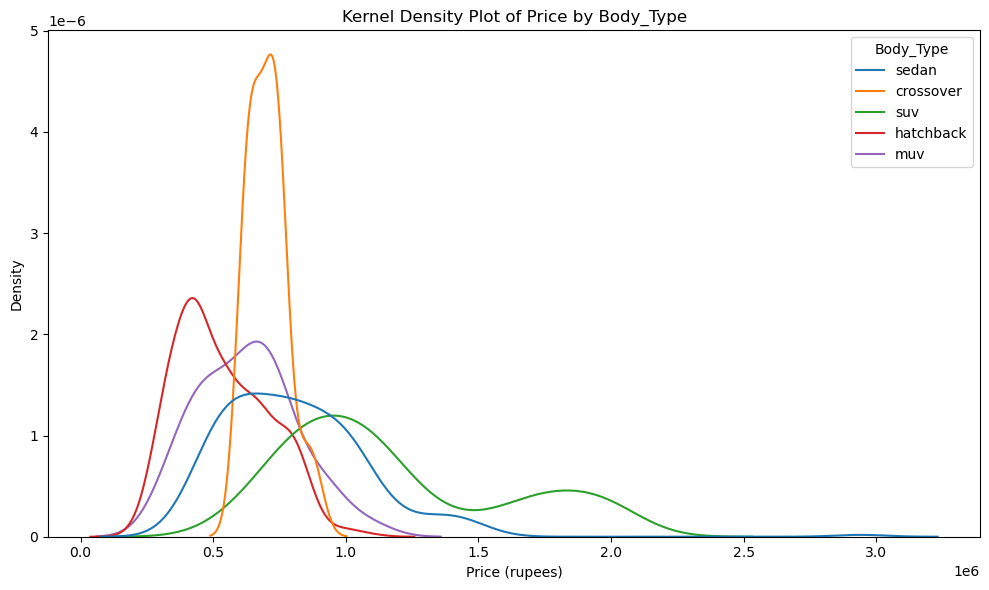


Mean / SD / Count by Body_Type
                   mean            std  count
Body_Type                                    
suv        1.176495e+06  417479.028217    206
sedan      8.097841e+05  286736.770092    227
crossover  7.050952e+05   72849.780207     21
muv        6.264211e+05  184093.488526     38
hatchback  5.339773e+05  173086.729837    484


In [45]:
df = pd.read_csv("./data/cars_hw.csv")
print(df["Price"].describe())
plt.figure(figsize=(9, 5))
sns.kdeplot(data=df, x="Price")
plt.title("Kernel Density Plot of Price")
plt.xlabel("Price (rupees)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()
body_summary = df.groupby("Body_Type")["Price"].describe()
print("\nprice summary by Body_Type")
print(body_summary)

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="Price", hue="Body_Type", common_norm=False)
plt.title("Kernel Density Plot of Price by Body_Type")
plt.xlabel("Price (rupees)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()
body_means_sds = (
    df.groupby("Body_Type")["Price"]
      .agg(["mean", "std", "count"])
      .sort_values("mean", ascending=False)
)
print("\nMean / SD / Count by Body_Type")
print(body_means_sds)

  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats? **59267 is the slope coefficient. The differences in price are not really roughly linear.**


In [46]:
m1 = smf.ols("Price ~ Seating_Capacity", data=df).fit()
print("\nRegression: Price ~ Seating_Capacity")
print(m1.summary())
print("\nCoefficients:")
print(m1.params)
# Seating_Capacity as one-hot-encoded
m2 = smf.ols("Price ~ C(Seating_Capacity)", data=df).fit()
print("\nRegression: Price ~ C(Seating_Capacity)")
print(m2.summary())
print("\nCoefficients:")
print(m2.params)
seat_means = df.groupby("Seating_Capacity")["Price"].mean()
print("\nMean Price by Seating_Capacity")
print(seat_means)



Regression: Price ~ Seating_Capacity
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Sun, 22 Mar 2026   Prob (F-statistic):             0.0245
Time:                        14:28:55   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
In

  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.  **Degree 8 gives the lowest cross validation RMSE.**


In [47]:
from sklearn.preprocessing import PolynomialFeatures
reference_year = df["Make_Year"].max()
df["Age"] = reference_year - df["Make_Year"]

X = df[["Age"]]
y = df["Price"]
cv = KFold(n_splits=10, shuffle=True, random_state=42)
cv_results = []
for degree in range(1, 9):
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("lr", LinearRegression())
    ])
    mse_scores = -cross_val_score(
        model, X, y,
        cv=cv,
        scoring="neg_mean_squared_error"
    )
    rmse_scores = np.sqrt(mse_scores)
    cv_results.append({
        "degree": degree,
        "mean_rmse": rmse_scores.mean(),
        "std_rmse": rmse_scores.std()
    })
cv_results = pd.DataFrame(cv_results)
print(cv_results)
best_degree = cv_results.loc[cv_results["mean_rmse"].idxmin(), "degree"]
print(f"best degree:{best_degree}")

   degree      mean_rmse      std_rmse
0       1  310765.360714  28322.052262
1       2  310779.295964  28494.476108
2       3  309697.344638  28822.899617
3       4  308871.567777  28694.823069
4       5  307368.981950  28095.274499
5       6  307522.523633  28086.577988
6       7  306433.419020  28062.995905
7       8  304974.926285  29464.687738
best degree:8


  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data? **Overall, yes since it reflects that price goes down as age goes up. However, it doesn't perfectly fit the data, since there's variation in price at each age that the model does not really explain.**


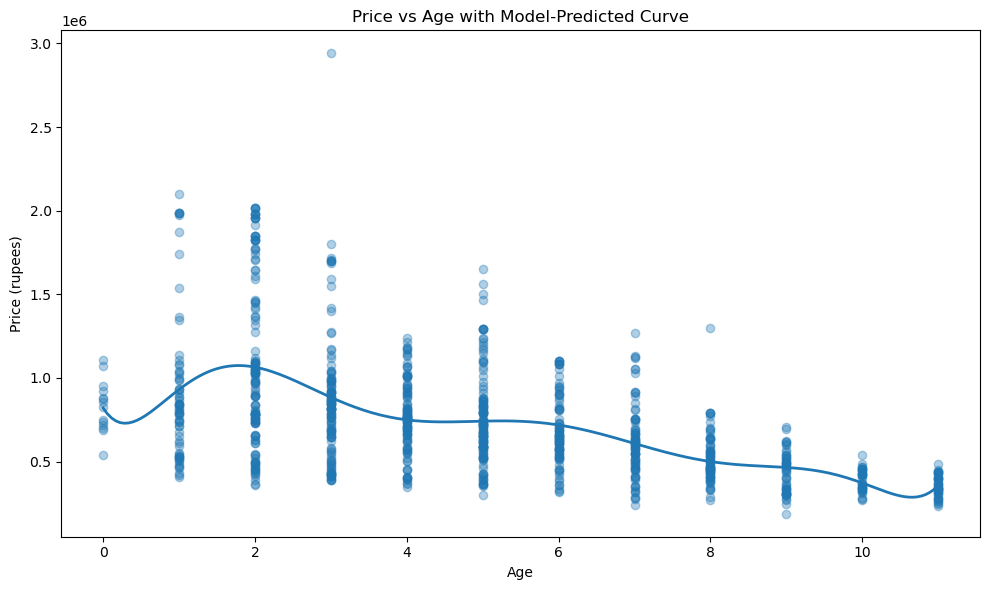

In [48]:
best_model = Pipeline([
    ("poly", PolynomialFeatures(degree=int(best_degree), include_bias=False)),
    ("lr", LinearRegression())
])
best_model.fit(X, y)
age_grid = np.linspace(df["Age"].min(), df["Age"].max(), 200)
pred_df = pd.DataFrame({"Age": age_grid})
pred_price = best_model.predict(pred_df[["Age"]])

plt.figure(figsize=(10, 6))
plt.scatter(df["Age"], df["Price"], alpha=0.35)
plt.plot(age_grid, pred_price, linewidth=2)
plt.title("Price vs Age with Model-Predicted Curve")
plt.xlabel("Age")
plt.ylabel("Price (rupees)")
plt.tight_layout()
plt.show()

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions? **The ATE is around 0.23.**


In [49]:
df = pd.read_csv("./data/heart_hw.csv")
survival_rates = df.groupby("transplant")["y"].mean()
control_survival = survival_rates["control"]
treatment_survival = survival_rates["treatment"]
ate = treatment_survival - control_survival
print(survival_rates)
print(f"\nControl survival rate:{control_survival:.6f}")
print(f"Treatment survival rate:{treatment_survival:.6f}")
print(f"ATE = treatment - control:{ate:.6f}")

transplant
control      0.117647
treatment    0.347826
Name: y, dtype: float64

Control survival rate:0.117647
Treatment survival rate:0.347826
ATE = treatment - control:0.230179


2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
**The intercept is the survival rate, and the treatment coefficient is the ATE from part 1.**

In [50]:
m1 = smf.ols("y ~ C(transplant)", data=df).fit()
print(m1.summary())
print("\nCoefficients:")
print(m1.params)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Sun, 22 Mar 2026   Prob (F-statistic):             0.0133
Time:                        14:28:56   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant? **Coefficient on transplant goes up by around 0.03 after controlling for age. The intercept and slope is the predicted survival probability for a control patient (age 0) and a one-year increase in age, respectively. ATE under-estimates the impact of a transplant until around age 53 where it intersects, and then from then on it over-estimates.**


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           0.000357
Time:                        14:28:56   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

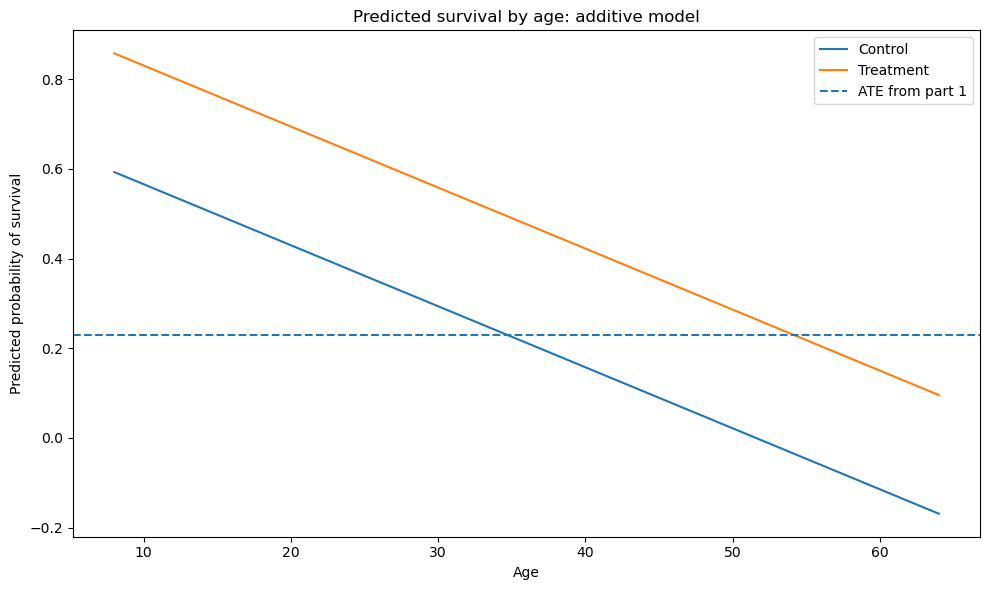

In [51]:
m2 = smf.ols("y ~ C(transplant) + age", data=df).fit()
print(m2.summary())
print("\nCoefficients:")
print(m2.params)
b0 = m2.params["Intercept"]
b_treat = m2.params["C(transplant)[T.treatment]"]
b_age = m2.params["age"]
print(f"\nIntercept: {b0:.6f}")
print(f"Transplant coefficient: {b_treat:.6f}")
print(f"Age coefficient: {b_age:.6f}")

age_grid = np.linspace(df["age"].min(), df["age"].max(), 200)
pred_control_m2 = b0 + b_age * age_grid
pred_treat_m2 = b0 + b_treat + b_age * age_grid
plt.figure(figsize=(10, 6))
plt.plot(age_grid, pred_control_m2, label="Control")
plt.plot(age_grid, pred_treat_m2, label="Treatment")
plt.axhline(ate, linestyle="--", label="ATE from part 1")
plt.xlabel("Age")
plt.ylabel("Predicted probability of survival")
plt.title("Predicted survival by age: additive model")
plt.legend()
plt.tight_layout()
plt.show()

4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice? **The prediction for transplant decreases as age increases. I notice a pattern that for younger patients, the model predicts a much larger transplant benefit, but for older patients, that benefit becomes smaller.**


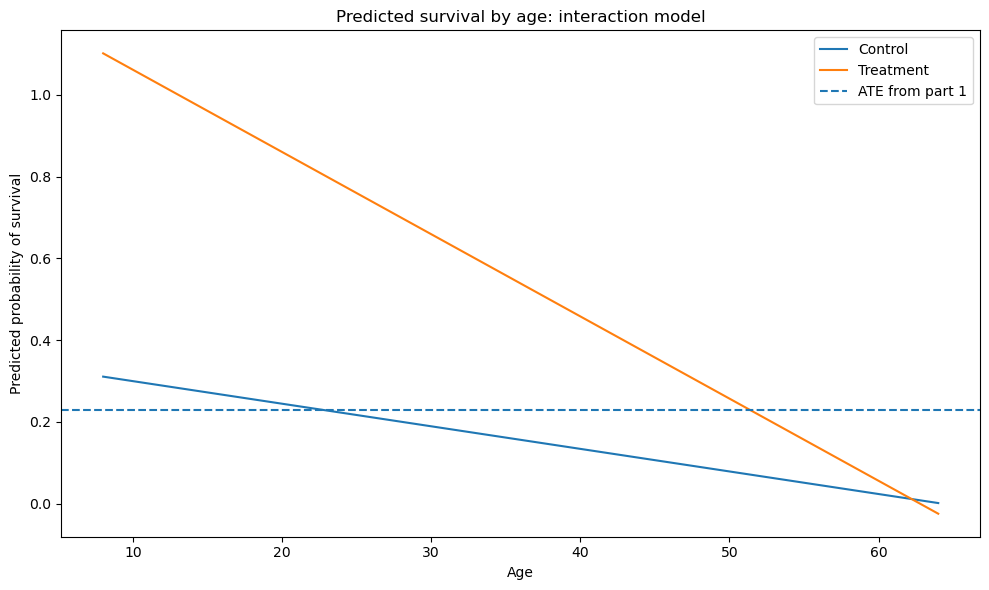

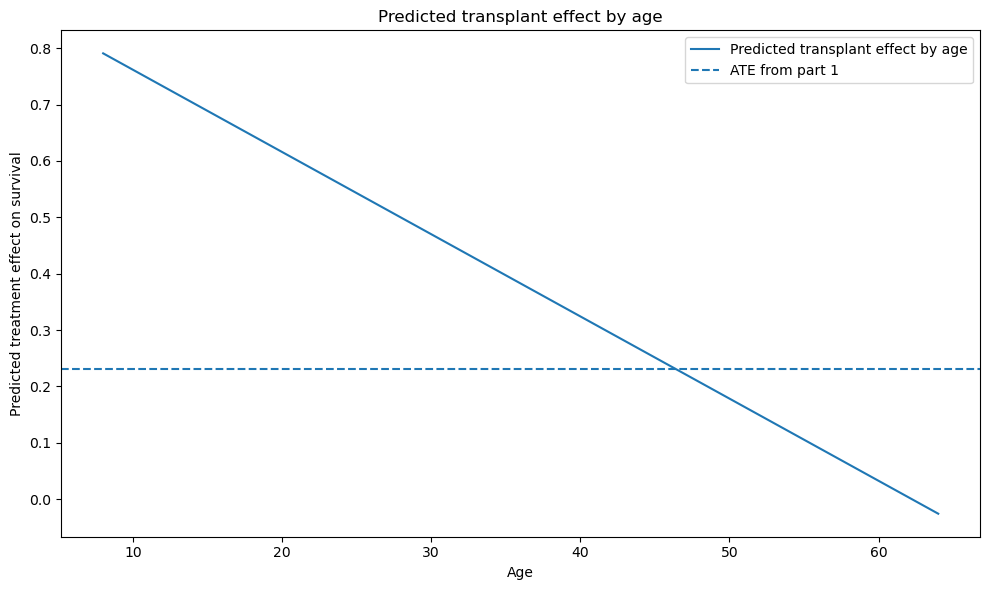

In [52]:
m3 = smf.ols("y ~ C(transplant) * age", data=df).fit()
c0 = m3.params["Intercept"]
c_treat = m3.params["C(transplant)[T.treatment]"]
c_age = m3.params["age"]
c_inter = m3.params["C(transplant)[T.treatment]:age"]
pred_control_m3 = c0 + c_age * age_grid
pred_treat_m3 = c0 + c_treat + (c_age + c_inter) * age_grid
treat_effect_by_age = c_treat + c_inter * age_grid

plt.figure(figsize=(10, 6))
plt.plot(age_grid, pred_control_m3, label="Control")
plt.plot(age_grid, pred_treat_m3, label="Treatment")
plt.axhline(ate, linestyle="--", label="ATE from part 1")
plt.xlabel("Age")
plt.ylabel("Predicted probability of survival")
plt.title("Predicted survival by age: interaction model")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(age_grid, treat_effect_by_age, label="Predicted transplant effect by age")
plt.axhline(ate, linestyle="--", label="ATE from part 1")
plt.xlabel("Age")
plt.ylabel("Predicted treatment effect on survival")
plt.title("Predicted transplant effect by age")
plt.legend()
plt.tight_layout()
plt.show()


5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 


In [53]:
cv = KFold(n_splits=10, shuffle=True, random_state=42)
def cv_rmse(formula, data):
    y_mat, X_mat = dmatrices(formula, data=data, return_type="dataframe") # chatGPT-inspired idea to use design matricies here.
    model = LinearRegression()
    rmse_scores = np.sqrt(
        -cross_val_score(
            model, X_mat, y_mat.values.ravel(),
            cv=cv, scoring="neg_mean_squared_error"
        )
    )
    return rmse_scores.mean(), rmse_scores.std()
rmse_m1 = cv_rmse("y ~ C(transplant)", df)
rmse_m2 = cv_rmse("y ~ C(transplant) + age", df)
rmse_m3 = cv_rmse("y ~ C(transplant) * age", df)
cv_table = pd.DataFrame({
    "model": [
        "y ~ transplant",
        "y ~ transplant + age",
        "y ~ transplant * age"
    ],
    "mean_rmse": [rmse_m1[0], rmse_m2[0], rmse_m3[0]],
    "sd_rmse": [rmse_m1[1], rmse_m2[1], rmse_m3[1]]
})
print(cv_table.sort_values("mean_rmse"))

                  model  mean_rmse   sd_rmse
2  y ~ transplant * age   0.412956  0.067735
1  y ~ transplant + age   0.416697  0.060250
0        y ~ transplant   0.436510  0.050276


6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment? **My concerns would be that there is a small sample size, so estimates may be unstable. Additionally, patients are not randomly assigned to transplants, so sicker/younger patients may be more likely to recieve treatment, thus making the interpretation of the transplant coefficient a little tricky. Finally, the model can also predict proabilities below 0 or above 1, which is not exactly ideal for a survival outcome which is binary.**
